In [ ]:


!pip -q install scikit-posthocs umap-learn thop


In [2]:

import os, re, gc, cv2, json, time, math, copy, random, zipfile, warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare, shapiro

try:
    import scikit_posthocs as sp
    POSTHOC_AVAILABLE = True
except Exception:
    POSTHOC_AVAILABLE = False

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.datasets.folder import default_loader
from torchvision import models as tvm

try:
    from thop import profile
    THOP_AVAILABLE = True
except Exception:
    THOP_AVAILABLE = False

warnings.filterwarnings("ignore")
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda available:', torch.cuda.is_available())


2026-04-21 13:11:24.567512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776777084.786224      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776777084.850993      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776777085.347571      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776777085.347612      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776777085.347615      55 computation_placer.cc:177] computation placer alr

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
cuda available: True


In [3]:

@dataclass
class MethodCfg:
    name: str
    backbone: str
    ssl_epochs: int
    batch_size_ssl: int
    lr_ssl: float
    proj_dim: int = 256
    hidden_dim: int = 512
    pred_dim: int = 256
    temperature: float = 0.2
    ema_momentum: float = 0.996
    dino_out_dim: int = 1024
    dino_teacher_temp: float = 0.04
    dino_student_temp: float = 0.1
    ablation_name: str = ''
    ablation_overrides: dict = field(default_factory=dict)

@dataclass
class CFG:
    EXP_NAME: str = 'task7_byol_40_60'
    IMAGE_SIZE: int = 224
    NUM_CLASSES: int = 11
    RANDOM_SEED: int = 42
    NUM_WORKERS: int = 2
    DEVICE: str = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Task 2 ratio grid
    TRAIN_RATIOS: Tuple[float, ...] = (0.40,)
    VAL_FRACTION_WITHIN_TRAIN: float = 0.10

    # Downstream / probe settings
    BATCH_SIZE_EVAL: int = 32
    LINEAR_PROBE_C_GRID: Tuple[float, ...] = (0.01, 0.1, 1.0, 10.0)
    LABEL_EFF_FRACS: Tuple[float, ...] = (0.01, 0.05, 0.10, 0.25, 0.50)

    # Checkpointing / resume
    SAVE_EVERY: int = 5
    RESUME: bool = True

    # Fine-grained control
    RUN_BASELINES: bool = True
    RUN_ABLATIONS: bool = True
    FAST_DEBUG: bool = False   # set True for quick smoke test

    # Supervised reference from Task 2 PDF
    SUPERVISED_BASELINE_NAME: str = 'MobileNet-V3-Large'
    SUPERVISED_BASELINE_90_10_ACC: float = 92.16
    SUPERVISED_BASELINE_GRID: dict = field(default_factory=lambda: {
        '90:10': 92.16,
        '80:20': 79.90,
        '70:30': 79.02,
        '60:40': 78.87,
        '50:50': 69.09,
        '40:60': 73.93,
        '30:70': 63.76,
        '20:80': 42.44,
        '10:90': 17.38,
    })

CFG = CFG()
METHODS = {
    'BYOL': MethodCfg(
        name='BYOL', backbone='vit_b_16', ssl_epochs=20, batch_size_ssl=16, lr_ssl=1e-3,
        ema_momentum=0.996,
        ablation_name='ema_0_99', ablation_overrides={'ema_momentum': 0.99}
    ),
}
if CFG.FAST_DEBUG:
    for m in METHODS.values():
        m.ssl_epochs = min(m.ssl_epochs, 2)
        m.batch_size_ssl = max(2, min(m.batch_size_ssl, 4))

ROOT_WORK = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
OUT_DIR = ROOT_WORK / CFG.EXP_NAME
CKPT_DIR = OUT_DIR / 'checkpoints'
TAB_DIR = OUT_DIR / 'tables'
FIG_DIR = OUT_DIR / 'figures'
LOG_DIR = OUT_DIR / 'logs'
for p in [OUT_DIR, CKPT_DIR, TAB_DIR, FIG_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Output dir:', OUT_DIR)
print('Methods:', {k: asdict(v) for k, v in METHODS.items()})


Output dir: /kaggle/working/task7_byol_40_60
Methods: {'BYOL': {'name': 'BYOL', 'backbone': 'vit_b_16', 'ssl_epochs': 20, 'batch_size_ssl': 16, 'lr_ssl': 0.001, 'proj_dim': 256, 'hidden_dim': 512, 'pred_dim': 256, 'temperature': 0.2, 'ema_momentum': 0.996, 'dino_out_dim': 1024, 'dino_teacher_temp': 0.04, 'dino_student_temp': 0.1, 'ablation_name': 'ema_0_99', 'ablation_overrides': {'ema_momentum': 0.99}}}


In [4]:

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.RANDOM_SEED)


def get_rng_state():
    state = {
        'python_random': random.getstate(),
        'numpy_random': np.random.get_state(),
        'torch_cpu': torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state['torch_cuda'] = torch.cuda.get_rng_state_all()
    return state


def set_rng_state(state):
    if state is None:
        return
    try:
        random.setstate(state['python_random'])
        np.random.set_state(state['numpy_random'])
        torch.set_rng_state(state['torch_cpu'])
        if torch.cuda.is_available() and 'torch_cuda' in state:
            torch.cuda.set_rng_state_all(state['torch_cuda'])
    except Exception as e:
        print('RNG restore skipped:', e)


In [5]:

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}


def contains_class_folders(root: Path) -> bool:
    if not root.exists() or not root.is_dir():
        return False
    subs = [d for d in root.iterdir() if d.is_dir()]
    if len(subs) < 2:
        return False
    good = 0
    for d in subs:
        try:
            if any(p.is_file() and p.suffix.lower() in IMAGE_EXTS for p in d.rglob('*')):
                good += 1
        except Exception:
            pass
    return good >= 2


def maybe_extract_dataset_zip(search_root: Path):
    unzip_dir = ROOT_WORK / 'unzipped_nematode_dataset'
    unzip_dir.mkdir(parents=True, exist_ok=True)
    for z in search_root.rglob('*.zip'):
        try:
            with zipfile.ZipFile(z, 'r') as zf:
                names = zf.namelist()[:100]
                if any('Microscopic Image Dataset of Plant-Parasitic Nematodes' in n for n in names):
                    print('Extracting dataset zip:', z)
                    zf.extractall(unzip_dir)
                    candidate = unzip_dir / 'Microscopic Image Dataset of Plant-Parasitic Nematodes'
                    if candidate.exists():
                        return candidate.resolve()
        except Exception:
            continue
    return None


def find_dataset_root():
    candidates = [Path('/kaggle/input'), Path('/kaggle/working'), Path('/mnt/data'), Path('.')]
    for base in candidates:
        if not base.exists():
            continue
        for p in [base] + list(base.rglob('*')):
            try:
                if p.is_dir() and p.name == 'Microscopic Image Dataset of Plant-Parasitic Nematodes' and contains_class_folders(p):
                    return p.resolve()
                if p.is_dir() and contains_class_folders(p):
                    child_names = [c.name for c in p.iterdir() if c.is_dir()]
                    if len(child_names) >= 2 and any('Genus' in c for c in child_names):
                        return p.resolve()
            except Exception:
                continue
    for base in candidates:
        if base.exists():
            ext = maybe_extract_dataset_zip(base)
            if ext is not None:
                return ext
    return None

DATASET_ROOT = find_dataset_root()
print('DATASET_ROOT:', DATASET_ROOT)
if DATASET_ROOT is None:
    raise FileNotFoundError('Dataset root not found. Attach the dataset zip or extracted dataset in Kaggle input.')


DATASET_ROOT: /kaggle/input/datasets/muradhasan10/nematoda/Microscopic Image Dataset of Plant-Parasitic Nematodes


In [6]:

def clean_class_name(folder_name: str) -> str:
    # turns 'Genus Criconemoides' -> 'Criconemoides'
    if folder_name.lower().startswith('genus '):
        return folder_name.split(' ', 1)[1].strip()
    return folder_name.strip()


def build_metadata_df(dataset_root: Path):
    rows = []
    class_dirs = [d for d in sorted(dataset_root.iterdir()) if d.is_dir()]
    cleaned_names = [clean_class_name(d.name) for d in class_dirs]
    label_map = {name: idx for idx, name in enumerate(cleaned_names)}
    for d in class_dirs:
        class_name = clean_class_name(d.name)
        label = label_map[class_name]
        files = sorted([p for p in d.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
        for fp in files:
            rows.append({'path': str(fp), 'class_name': class_name, 'label': label, 'raw_dir': d.name})
    df = pd.DataFrame(rows)
    return df, label_map


def extract_group_id(path_str: str) -> str:
    name = Path(path_str).stem.lower()
    # if explicit IDs exist, use them; otherwise default to full stem (safe, near-unique)
    m = re.search(r'(id\d+|specimen\d+|sample\d+|source\d+|img\d+)', name)
    if m:
        return m.group(1)
    return name

full_df, label_map = build_metadata_df(DATASET_ROOT)
full_df['group_id'] = full_df['path'].apply(extract_group_id)
idx_to_label = {v: k for k, v in label_map.items()}

print('Total images:', len(full_df))
print('Classes:', len(label_map))
display(full_df.head())
display(full_df['class_name'].value_counts().sort_index().to_frame('count'))


Total images: 1016
Classes: 11


,path,class_name,label,raw_dir,group_id
0,/kaggle/input/datasets/muradhasan10/nematoda/M...,Criconema,0,Genus Criconema,criconema (1)
1,/kaggle/input/datasets/muradhasan10/nematoda/M...,Criconema,0,Genus Criconema,criconema (2)
2,/kaggle/input/datasets/muradhasan10/nematoda/M...,Criconema,0,Genus Criconema,criconema (3)
3,/kaggle/input/datasets/muradhasan10/nematoda/M...,Criconema,0,Genus Criconema,criconema (4)
4,/kaggle/input/datasets/muradhasan10/nematoda/M...,Criconemoides,1,Genus Criconemoides,criconemoides (1)


,count
class_name,
Criconema,4
Criconemoides,103
Helicotylenchus,135
Hemicycliophora,6
Hirschmaniella,130
Hoplolaimus,151
Meloidogyne,211
Pratylenchus,116
Radopholus,31


In [7]:

def stratified_group_split(df: pd.DataFrame, train_ratio: float, val_fraction_within_train: float, seed: int):
    # Step 1: train+val vs test using groups
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_ratio, random_state=seed)
    trainval_idx, test_idx = next(gss1.split(df, y=df['label'], groups=df['group_id']))
    trainval = df.iloc[trainval_idx].reset_index(drop=True)
    test = df.iloc[test_idx].reset_index(drop=True)

    # Step 2: within the trainval portion, reserve 10% of that trainval portion as validation
    # IMPORTANT: do NOT divide by train_ratio here. For a 10:90 split, dividing would make
    # test_size=1.0 and crash GroupShuffleSplit. Since trainval already represents the chosen
    # training portion, the validation fraction should be used directly.
    val_abs_fraction = val_fraction_within_train
    if not (0.0 < val_abs_fraction < 1.0):
        raise ValueError(f'Validation fraction must be in (0, 1), got {val_abs_fraction}')
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_abs_fraction, random_state=seed + 17)
    train_idx, val_idx = next(gss2.split(trainval, y=trainval['label'], groups=trainval['group_id']))
    train = trainval.iloc[train_idx].reset_index(drop=True)
    val = trainval.iloc[val_idx].reset_index(drop=True)
    return train, val, test


def ratio_to_name(train_ratio: float) -> str:
    train_pct = int(round(train_ratio * 100))
    test_pct = 100 - train_pct
    return f'{train_pct}:{test_pct}'

SPLITS = {}
for tr in CFG.TRAIN_RATIOS:
    train_df, val_df, test_df = stratified_group_split(full_df, tr, CFG.VAL_FRACTION_WITHIN_TRAIN, CFG.RANDOM_SEED + int(tr * 1000))
    SPLITS[tr] = {'train': train_df, 'val': val_df, 'test': test_df}
    print(ratio_to_name(tr), '->', len(train_df), len(val_df), len(test_df), 'group overlaps:',
          len(set(train_df.group_id) & set(test_df.group_id)), len(set(val_df.group_id) & set(test_df.group_id)))


40:60 -> 365 41 610 group overlaps: 0 0


In [8]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def build_ssl_pair_transform(image_size=224, remove_color_jitter=False):
    ops = [
        T.RandomResizedCrop(image_size, scale=(0.6, 1.0), interpolation=InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(p=0.5),
    ]
    if not remove_color_jitter:
        ops.append(T.RandomApply([T.ColorJitter(0.4, 0.4, 0.2, 0.1)], p=0.8))
    ops += [
        T.RandomGrayscale(p=0.2),
        T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    return T.Compose(ops)


class PairTransform:
    def __init__(self, image_size=224, remove_color_jitter=False):
        self.t = build_ssl_pair_transform(image_size, remove_color_jitter=remove_color_jitter)
    def __call__(self, img):
        return self.t(img), self.t(img)


class DinoTransform:
    def __init__(self, image_size=224, remove_color_jitter=False):
        self.g1 = build_ssl_pair_transform(image_size, remove_color_jitter=remove_color_jitter)
        self.g2 = build_ssl_pair_transform(image_size, remove_color_jitter=remove_color_jitter)
    def __call__(self, img):
        return [self.g1(img), self.g2(img)]


def build_eval_transform(image_size=224):
    return T.Compose([
        T.Resize((image_size, image_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

EVAL_TRANSFORM = build_eval_transform(CFG.IMAGE_SIZE)


In [9]:

class SSLImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.loader = default_loader
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img = self.loader(self.df.iloc[idx]['path']).convert('RGB')
        return self.transform(img)


class LabeledImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.loader = default_loader
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.loader(row['path']).convert('RGB')
        return self.transform(img), int(row['label'])


def build_loaders_for_split(split_df: dict, method_name: str, method_cfg: MethodCfg, ablation: bool = False):
    overrides = method_cfg.ablation_overrides if ablation else {}
    remove_color_jitter = overrides.get('remove_color_jitter', False)
    ssl_tfm = DinoTransform(CFG.IMAGE_SIZE, remove_color_jitter) if method_name == 'DINO' else PairTransform(CFG.IMAGE_SIZE, remove_color_jitter)

    batch_ssl = overrides.get('batch_size_ssl', method_cfg.batch_size_ssl)

    train_ssl_ds = SSLImageDataset(split_df['train'], ssl_tfm)
    tr_ssl_loader = DataLoader(train_ssl_ds, batch_size=batch_ssl, shuffle=True,
                               num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)

    tr_eval_loader = DataLoader(LabeledImageDataset(split_df['train'], EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_EVAL,
                                shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    va_eval_loader = DataLoader(LabeledImageDataset(split_df['val'], EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_EVAL,
                                shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    te_eval_loader = DataLoader(LabeledImageDataset(split_df['test'], EVAL_TRANSFORM), batch_size=CFG.BATCH_SIZE_EVAL,
                                shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    return tr_ssl_loader, tr_eval_loader, va_eval_loader, te_eval_loader


In [10]:

def build_backbone(backbone_name: str, pretrained: bool = True):
    name = backbone_name.lower()
    if name == 'resnet101':
        weights = tvm.ResNet101_Weights.DEFAULT if pretrained else None
        net = tvm.resnet101(weights=weights)
        feat_dim = net.fc.in_features
        net.fc = nn.Identity()
        return net, feat_dim
    if name == 'mobilenet_v3_large':
        weights = tvm.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        net = tvm.mobilenet_v3_large(weights=weights)
        feat_dim = net.classifier[-1].in_features
        net.classifier = nn.Identity()
        return net, feat_dim
    if name in ['vit_b_16', 'vit-b/16', 'vit_b16']:
        weights = tvm.ViT_B_16_Weights.DEFAULT if pretrained else None
        net = tvm.vit_b_16(weights=weights)
        feat_dim = net.heads.head.in_features
        net.heads.head = nn.Identity()
        return net, feat_dim
    raise ValueError(f'Unknown backbone: {backbone_name}')


class MLPHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, use_bn=True):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim)]
        if use_bn:
            layers.append(nn.BatchNorm1d(hidden_dim))
        layers += [nn.ReLU(inplace=True), nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


class Predictor(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)


In [11]:

class SimCLRModel(nn.Module):
    def __init__(self, method_cfg: MethodCfg):
        super().__init__()
        self.backbone, feat_dim = build_backbone(method_cfg.backbone, pretrained=True)
        self.proj = MLPHead(feat_dim, method_cfg.hidden_dim, method_cfg.proj_dim)
        self.temperature = method_cfg.temperature
    def encode(self, x):
        return self.backbone(x)
    def forward(self, x):
        h = self.backbone(x)
        z = self.proj(h)
        z = F.normalize(z, dim=1)
        return z


class BYOLModel(nn.Module):
    def __init__(self, method_cfg: MethodCfg):
        super().__init__()
        self.online_backbone, feat_dim = build_backbone(method_cfg.backbone, pretrained=True)
        self.online_proj = MLPHead(feat_dim, method_cfg.hidden_dim, method_cfg.proj_dim)
        self.online_pred = Predictor(method_cfg.proj_dim, method_cfg.hidden_dim, method_cfg.pred_dim)

        self.target_backbone, _ = build_backbone(method_cfg.backbone, pretrained=True)
        self.target_proj = MLPHead(feat_dim, method_cfg.hidden_dim, method_cfg.proj_dim)
        self.ema_momentum = method_cfg.ema_momentum
        self._init_target()

    def _init_target(self):
        self.target_backbone.load_state_dict(self.online_backbone.state_dict())
        self.target_proj.load_state_dict(self.online_proj.state_dict())
        for p in self.target_backbone.parameters():
            p.requires_grad = False
        for p in self.target_proj.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update_target(self):
        m = self.ema_momentum
        for op, tp in zip(self.online_backbone.parameters(), self.target_backbone.parameters()):
            tp.data = tp.data * m + op.data * (1. - m)
        for op, tp in zip(self.online_proj.parameters(), self.target_proj.parameters()):
            tp.data = tp.data * m + op.data * (1. - m)

    def encode(self, x):
        return self.online_backbone(x)

    def forward(self, x1, x2):
        h1 = self.online_backbone(x1)
        h2 = self.online_backbone(x2)
        z1 = self.online_proj(h1)
        z2 = self.online_proj(h2)
        p1 = self.online_pred(z1)
        p2 = self.online_pred(z2)
        with torch.no_grad():
            t1 = self.target_proj(self.target_backbone(x1))
            t2 = self.target_proj(self.target_backbone(x2))
        return p1, p2, t1.detach(), t2.detach()


class DINOLoss(nn.Module):
    def __init__(self, out_dim, teacher_temp=0.04, student_temp=0.1, center_momentum=0.9):
        super().__init__()
        self.teacher_temp = teacher_temp
        self.student_temp = student_temp
        self.center_momentum = center_momentum
        self.register_buffer('center', torch.zeros(1, out_dim))

    def forward(self, student_out, teacher_out):
        student = student_out / self.student_temp
        student_logprob = F.log_softmax(student, dim=-1)
        teacher_prob = F.softmax((teacher_out - self.center) / self.teacher_temp, dim=-1)
        loss = torch.sum(-teacher_prob * student_logprob, dim=-1).mean()
        with torch.no_grad():
            batch_center = teacher_out.mean(dim=0, keepdim=True)
            self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)
        return loss


class DINOModel(nn.Module):
    def __init__(self, method_cfg: MethodCfg):
        super().__init__()
        self.student_backbone, feat_dim = build_backbone(method_cfg.backbone, pretrained=True)
        self.student_head = MLPHead(feat_dim, method_cfg.hidden_dim, method_cfg.dino_out_dim, use_bn=False)

        self.teacher_backbone, _ = build_backbone(method_cfg.backbone, pretrained=True)
        self.teacher_head = MLPHead(feat_dim, method_cfg.hidden_dim, method_cfg.dino_out_dim, use_bn=False)
        self.ema_momentum = method_cfg.ema_momentum
        self._init_teacher()

    def _init_teacher(self):
        self.teacher_backbone.load_state_dict(self.student_backbone.state_dict())
        self.teacher_head.load_state_dict(self.student_head.state_dict())
        for p in self.teacher_backbone.parameters():
            p.requires_grad = False
        for p in self.teacher_head.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update_teacher(self):
        m = self.ema_momentum
        for sp, tp in zip(self.student_backbone.parameters(), self.teacher_backbone.parameters()):
            tp.data = tp.data * m + sp.data * (1. - m)
        for sp, tp in zip(self.student_head.parameters(), self.teacher_head.parameters()):
            tp.data = tp.data * m + sp.data * (1. - m)

    def encode(self, x):
        return self.student_backbone(x)

    def forward(self, views):
        v1, v2 = views
        s1 = self.student_head(self.student_backbone(v1))
        s2 = self.student_head(self.student_backbone(v2))
        with torch.no_grad():
            t1 = self.teacher_head(self.teacher_backbone(v1))
            t2 = self.teacher_head(self.teacher_backbone(v2))
        return s1, s2, t1.detach(), t2.detach()


In [12]:

def nt_xent_loss(z1, z2, temperature=0.2):
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t()) / temperature
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -1e9)
    positives = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)], dim=0)
    numerator = torch.exp(positives)
    denominator = torch.exp(sim).sum(dim=1)
    loss = -torch.log(numerator / denominator).mean()
    return loss


def byol_loss_fn(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()


In [13]:

def save_checkpoint(path: Path, payload: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)


def load_checkpoint(path: Path, model=None, optimizer=None):
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    if model is not None:
        model.load_state_dict(ckpt['model_state'])
    if optimizer is not None and ckpt.get('optimizer_state') is not None:
        optimizer.load_state_dict(ckpt['optimizer_state'])
    if ckpt.get('rng_state') is not None:
        set_rng_state(ckpt['rng_state'])
    return ckpt


def get_ckpt_paths(method_name: str, ratio_name: str, tag: str = 'baseline'):
    base = CKPT_DIR / method_name / ratio_name / tag
    return base / 'latest.pt', base / 'best.pt'


def train_ssl(method_name: str, method_cfg: MethodCfg, ratio_name: str, split_df: dict, ablation: bool = False):
    tag = 'ablation' if ablation else 'baseline'
    latest_ckpt, best_ckpt = get_ckpt_paths(method_name, ratio_name, tag=tag)

    # copy cfg and apply ablation overrides only for the ablation branch
    local_cfg = copy.deepcopy(method_cfg)
    if ablation:
        for k, v in local_cfg.ablation_overrides.items():
            if hasattr(local_cfg, k):
                setattr(local_cfg, k, v)

    tr_ssl_loader, tr_eval_loader, va_eval_loader, te_eval_loader = build_loaders_for_split(split_df, method_name, local_cfg, ablation=ablation)

    if method_name == 'SimCLR':
        model = SimCLRModel(local_cfg).to(CFG.DEVICE)
    elif method_name == 'BYOL':
        model = BYOLModel(local_cfg).to(CFG.DEVICE)
    elif method_name == 'DINO':
        model = DINOModel(local_cfg).to(CFG.DEVICE)
    else:
        raise ValueError(method_name)

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=local_cfg.lr_ssl, weight_decay=1e-4)

    start_epoch = 0
    history = []
    best_loss = np.inf
    if CFG.RESUME and latest_ckpt.exists():
        print(f'Resuming {method_name} {ratio_name} {tag} from', latest_ckpt)
        ckpt = load_checkpoint(latest_ckpt, model=model, optimizer=optimizer)
        start_epoch = ckpt.get('epoch', 0) + 1
        best_loss = ckpt.get('best_loss', np.inf)
        history = ckpt.get('history', [])

    epochs = local_cfg.ssl_epochs
    model.train()

    if len(tr_ssl_loader) == 0:
        raise RuntimeError(f'SSL loader for {method_name} / {ratio_name} is empty. Increase batch size?')

    for epoch in range(start_epoch, epochs):
        t0 = time.time()
        losses = []
        for batch in tr_ssl_loader:
            optimizer.zero_grad(set_to_none=True)
            if method_name in ['SimCLR', 'BYOL']:
                x1, x2 = batch
                x1 = x1.to(CFG.DEVICE, non_blocking=True)
                x2 = x2.to(CFG.DEVICE, non_blocking=True)
            else:
                x1, x2 = batch[0], batch[1]
                x1 = x1.to(CFG.DEVICE, non_blocking=True)
                x2 = x2.to(CFG.DEVICE, non_blocking=True)

            if method_name == 'SimCLR':
                z1 = model(x1)
                z2 = model(x2)
                loss = nt_xent_loss(z1, z2, temperature=local_cfg.temperature)
            elif method_name == 'BYOL':
                p1, p2, t1, t2 = model(x1, x2)
                loss = byol_loss_fn(p1, t2) + byol_loss_fn(p2, t1)
            elif method_name == 'DINO':
                s1, s2, t1, t2 = model([x1, x2])
                dino_loss = DINOLoss(local_cfg.dino_out_dim, local_cfg.dino_teacher_temp, local_cfg.dino_student_temp, 0.9).to(CFG.DEVICE)
                loss = dino_loss(s1, t2) + dino_loss(s2, t1)
            loss.backward()
            optimizer.step()
            if method_name == 'BYOL':
                model.update_target()
            if method_name == 'DINO':
                model.update_teacher()
            losses.append(float(loss.item()))

        epoch_loss = float(np.mean(losses)) if losses else np.nan
        elapsed = time.time() - t0
        history.append({'epoch': epoch, 'ssl_loss': epoch_loss, 'elapsed_sec': elapsed})
        print(f'[{method_name}][{ratio_name}][{tag}] epoch {epoch+1}/{epochs} ssl_loss={epoch_loss:.4f} time={elapsed:.1f}s')
        payload = {
            'epoch': epoch,
            'method_name': method_name,
            'ratio_name': ratio_name,
            'tag': tag,
            'config': asdict(local_cfg),
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_loss': best_loss,
            'history': history,
            'rng_state': get_rng_state(),
        }
        save_checkpoint(latest_ckpt, payload)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            payload['best_loss'] = best_loss
            save_checkpoint(best_ckpt, payload)

        if (epoch + 1) % CFG.SAVE_EVERY == 0:
            pd.DataFrame(history).to_csv(LOG_DIR / f'{method_name}_{ratio_name}_{tag}_ssl_history.csv', index=False)

    if best_ckpt.exists():
        load_checkpoint(best_ckpt, model=model)
    model.eval()
    return model, history


In [14]:

@torch.no_grad()
def extract_features(model, loader, method_name: str):
    model.eval()
    feats, ys = [], []
    for xb, yb in loader:
        xb = xb.to(CFG.DEVICE, non_blocking=True)
        if method_name == 'SimCLR':
            h = model.encode(xb)
        elif method_name == 'BYOL':
            h = model.encode(xb)
        elif method_name == 'DINO':
            h = model.encode(xb)
        else:
            raise ValueError(method_name)
        feats.append(h.detach().cpu().numpy())
        ys.append(yb.numpy())
    X = np.concatenate(feats, axis=0)
    y = np.concatenate(ys, axis=0)
    return X, y


def fit_linear_probe(X_train, y_train, X_val, y_val):
    best_model, best_acc, best_c = None, -1.0, None
    for c in CFG.LINEAR_PROBE_C_GRID:
        clf = LogisticRegression(C=c, max_iter=2000, multi_class='multinomial', class_weight='balanced', n_jobs=None)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_val)
        acc = accuracy_score(y_val, preds)
        if acc > best_acc:
            best_acc = acc
            best_model = clf
            best_c = c
    return best_model, best_c, best_acc


def compute_all_metrics(y_true, probs, num_classes):
    y_pred = probs.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    y_bin = label_binarize(y_true, classes=list(range(num_classes)))
    try:
        auc_macro = roc_auc_score(y_bin, probs, average='macro', multi_class='ovr')
    except Exception:
        auc_macro = np.nan
    return {
        'accuracy': float(acc),
        'macro_precision': float(prec),
        'macro_recall': float(rec),
        'macro_f1': float(f1),
        'roc_auc_ovr_macro': float(auc_macro) if auc_macro == auc_macro else np.nan,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_pred, zero_division=0, output_dict=True),
    }


def run_linear_probe_and_label_efficiency(model, method_name: str, ratio_name: str, loaders: tuple):
    tr_eval_loader, va_eval_loader, te_eval_loader = loaders
    X_tr, y_tr = extract_features(model, tr_eval_loader, method_name)
    X_va, y_va = extract_features(model, va_eval_loader, method_name)
    X_te, y_te = extract_features(model, te_eval_loader, method_name)

    t0 = time.time()
    lp_model, best_c, val_acc = fit_linear_probe(X_tr, y_tr, X_va, y_va)
    train_time = time.time() - t0

    t1 = time.time()
    probs = lp_model.predict_proba(X_te)
    test_time = time.time() - t1
    metrics = compute_all_metrics(y_te, probs, CFG.NUM_CLASSES)

    # kNN on frozen features
    knn1 = KNeighborsClassifier(n_neighbors=1)
    knn5 = KNeighborsClassifier(n_neighbors=5)
    knn1.fit(X_tr, y_tr)
    knn5.fit(X_tr, y_tr)
    knn1_acc = accuracy_score(y_te, knn1.predict(X_te))
    knn5_acc = accuracy_score(y_te, knn5.predict(X_te))

    # label efficiency
    label_eff_rows = []
    for frac in CFG.LABEL_EFF_FRACS:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max(frac, min(0.5, frac)), random_state=CFG.RANDOM_SEED)
        try:
            idx, _ = next(sss.split(X_tr, y_tr))
            X_small, y_small = X_tr[idx], y_tr[idx]
        except Exception:
            # fallback if a very small class count causes stratify failure
            n_small = max(CFG.NUM_CLASSES * 2, int(len(X_tr) * frac))
            idx = np.random.RandomState(CFG.RANDOM_SEED).choice(len(X_tr), size=min(n_small, len(X_tr)), replace=False)
            X_small, y_small = X_tr[idx], y_tr[idx]

        lp_small, small_c, _ = fit_linear_probe(X_small, y_small, X_va, y_va)
        small_probs = lp_small.predict_proba(X_te)
        small_metrics = compute_all_metrics(y_te, small_probs, CFG.NUM_CLASSES)
        label_eff_rows.append({
            'ratio': ratio_name,
            'label_frac': frac,
            'lp_accuracy': small_metrics['accuracy'],
            'macro_f1': small_metrics['macro_f1'],
            'roc_auc_ovr_macro': small_metrics['roc_auc_ovr_macro'],
            'best_c': small_c,
            'n_train_labels': len(y_small),
        })

    return {
        'features': {'X_tr': X_tr, 'y_tr': y_tr, 'X_va': X_va, 'y_va': y_va, 'X_te': X_te, 'y_te': y_te},
        'linear_probe_metrics': metrics,
        'linear_probe_best_c': best_c,
        'linear_probe_val_acc': val_acc,
        'linear_probe_train_time_sec': train_time,
        'linear_probe_test_time_sec': test_time,
        'knn1_acc': float(knn1_acc),
        'knn5_acc': float(knn5_acc),
        'label_efficiency': pd.DataFrame(label_eff_rows),
    }


In [15]:

def maybe_profile_gflops(model, input_size=224):
    if not THOP_AVAILABLE:
        return np.nan, np.nan
    try:
        model_cpu = copy.deepcopy(model).cpu().eval()
        dummy = torch.randn(1, 3, input_size, input_size)
        macs, params = profile(model_cpu, inputs=(dummy,), verbose=False)
        gflops = (2 * macs) / 1e9
        return float(gflops), int(params)
    except Exception:
        return np.nan, np.nan


def run_single_experiment(method_name: str, method_cfg: MethodCfg, train_ratio: float, ablation: bool = False):
    ratio_name = ratio_to_name(train_ratio)
    split_df = SPLITS[train_ratio] if train_ratio in SPLITS else SPLITS[CFG.TRAIN_RATIOS[0]]
    print(' ' + '=' * 90)
    print(f'Running {method_name} | ratio={ratio_name} | ablation={ablation}')
    print('=' * 90)

    ssl_t0 = time.time()
    model, history = train_ssl(method_name, method_cfg, ratio_name, split_df, ablation=ablation)
    ssl_train_time = time.time() - ssl_t0

    tr_ssl_loader, tr_eval_loader, va_eval_loader, te_eval_loader = build_loaders_for_split(split_df, method_name, method_cfg, ablation=ablation)
    downstream = run_linear_probe_and_label_efficiency(model, method_name, ratio_name, (tr_eval_loader, va_eval_loader, te_eval_loader))
    gflops, params = maybe_profile_gflops(model.backbone if hasattr(model, 'backbone') else getattr(model, 'online_backbone', getattr(model, 'student_backbone', model)), CFG.IMAGE_SIZE)

    row = {
        'method': method_name,
        'backbone': method_cfg.backbone,
        'ratio': ratio_name,
        'train_ratio': train_ratio,
        'tag': 'ablation' if ablation else 'baseline',
        'ssl_epochs': method_cfg.ssl_epochs,
        'ssl_train_time_sec': ssl_train_time,
        'ssl_final_loss': float(history[-1]['ssl_loss']) if history else np.nan,
        'lp_accuracy': downstream['linear_probe_metrics']['accuracy'] * 100.0,
        'lp_macro_f1': downstream['linear_probe_metrics']['macro_f1'] * 100.0,
        'lp_roc_auc': downstream['linear_probe_metrics']['roc_auc_ovr_macro'],
        'knn1_acc': downstream['knn1_acc'] * 100.0,
        'knn5_acc': downstream['knn5_acc'] * 100.0,
        'probe_train_time_sec': downstream['linear_probe_train_time_sec'],
        'probe_test_time_sec': downstream['linear_probe_test_time_sec'],
        'best_c': downstream['linear_probe_best_c'],
        'gflops_backbone': gflops,
        'params_backbone': params,
        'train_n': len(split_df['train']),
        'val_n': len(split_df['val']),
        'test_n': len(split_df['test']),
    }
    label_eff_df = downstream['label_efficiency'].copy()
    label_eff_df['method'] = method_name
    label_eff_df['backbone'] = method_cfg.backbone
    label_eff_df['tag'] = row['tag']

    # save ratio-level outputs immediately
    pd.DataFrame(history).to_csv(LOG_DIR / f'{method_name}_{ratio_name}_{row["tag"]}_ssl_history.csv', index=False)
    label_eff_df.to_csv(TAB_DIR / f'{method_name}_{ratio_name}_{row["tag"]}_label_efficiency.csv', index=False)

    cm = downstream['linear_probe_metrics']['confusion_matrix']
    np.save(TAB_DIR / f'{method_name}_{ratio_name}_{row["tag"]}_confusion_matrix.npy', cm)

    feats = downstream['features']
    np.savez(
        TAB_DIR / f'{method_name}_{ratio_name}_{row["tag"]}_features_test.npz',
        X_te=feats['X_te'], y_te=feats['y_te'], X_tr=feats['X_tr'], y_tr=feats['y_tr']
    )

    with open(TAB_DIR / f'{method_name}_{ratio_name}_{row["tag"]}_classification_report.json', 'w') as f:
        json.dump(downstream['linear_probe_metrics']['classification_report'], f, indent=2)

    del model, tr_ssl_loader, tr_eval_loader, va_eval_loader, te_eval_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row, label_eff_df


In [16]:

results_rows = []
label_eff_tables = []

if CFG.RUN_BASELINES:
    for method_name, method_cfg in METHODS.items():
        for tr in CFG.TRAIN_RATIOS:
            row, le = run_single_experiment(method_name, method_cfg, tr, ablation=False)
            results_rows.append(row)
            label_eff_tables.append(le)

if CFG.RUN_ABLATIONS:
    best_split = CFG.TRAIN_RATIOS[0]
    for method_name, method_cfg in METHODS.items():
        row, le = run_single_experiment(method_name, method_cfg, best_split, ablation=True)
        results_rows.append(row)
        label_eff_tables.append(le)

results_df = pd.DataFrame(results_rows)
label_eff_df = pd.concat(label_eff_tables, ignore_index=True) if label_eff_tables else pd.DataFrame()

results_df.to_csv(TAB_DIR / 'task7_ratio_results.csv', index=False)
label_eff_df.to_csv(TAB_DIR / 'task7_label_efficiency_results.csv', index=False)

print('Saved:', TAB_DIR / 'task7_ratio_results.csv')
print('Saved:', TAB_DIR / 'task7_label_efficiency_results.csv')
display(results_df.head())
display(label_eff_df.head())


Running BYOL | ratio=40:60 | ablation=False
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 167MB/s]  


[BYOL][40:60][baseline] epoch 1/20 ssl_loss=2.0170 time=48.3s
[BYOL][40:60][baseline] epoch 2/20 ssl_loss=1.7022 time=51.3s
[BYOL][40:60][baseline] epoch 3/20 ssl_loss=1.5992 time=57.7s
[BYOL][40:60][baseline] epoch 4/20 ssl_loss=1.5903 time=57.9s
[BYOL][40:60][baseline] epoch 5/20 ssl_loss=1.5789 time=57.0s
[BYOL][40:60][baseline] epoch 6/20 ssl_loss=1.5631 time=57.3s
[BYOL][40:60][baseline] epoch 7/20 ssl_loss=1.5152 time=57.3s
[BYOL][40:60][baseline] epoch 8/20 ssl_loss=1.3313 time=57.9s
[BYOL][40:60][baseline] epoch 9/20 ssl_loss=1.2734 time=56.9s
[BYOL][40:60][baseline] epoch 10/20 ssl_loss=1.4228 time=56.6s
[BYOL][40:60][baseline] epoch 11/20 ssl_loss=1.3473 time=56.4s
[BYOL][40:60][baseline] epoch 12/20 ssl_loss=1.3648 time=57.1s
[BYOL][40:60][baseline] epoch 13/20 ssl_loss=1.6476 time=56.9s
[BYOL][40:60][baseline] epoch 14/20 ssl_loss=1.7497 time=57.2s
[BYOL][40:60][baseline] epoch 15/20 ssl_loss=1.7769 time=56.3s
[BYOL][40:60][baseline] epoch 16/20 ssl_loss=1.4854 time=56.3s
[

,method,backbone,ratio,train_ratio,tag,ssl_epochs,ssl_train_time_sec,ssl_final_loss,lp_accuracy,lp_macro_f1,...,knn1_acc,knn5_acc,probe_train_time_sec,probe_test_time_sec,best_c,gflops_backbone,params_backbone,train_n,val_n,test_n
0,BYOL,vit_b_16,40:60,0.4,baseline,20,1201.205968,1.801817,8.196721,8.310040,...,19.180328,15.901639,23.333658,0.010278,1.0,22.570973,57298176,365,41,610
1,BYOL,vit_b_16,40:60,0.4,ablation,20,1201.847822,1.495909,13.278689,11.606809,...,20.655738,22.622951,21.506575,0.010552,10.0,22.570973,57298176,365,41,610


,ratio,label_frac,lp_accuracy,macro_f1,roc_auc_ovr_macro,best_c,n_train_labels,method,backbone,tag
0,40:60,0.01,0.027869,0.019185,0.494709,0.01,22,BYOL,vit_b_16,baseline
1,40:60,0.05,0.027869,0.019185,0.494709,0.01,22,BYOL,vit_b_16,baseline
2,40:60,0.10,0.031148,0.045775,0.525455,0.01,36,BYOL,vit_b_16,baseline
3,40:60,0.25,0.108197,0.081047,0.543306,10.00,91,BYOL,vit_b_16,baseline
4,40:60,0.50,0.047541,0.050185,0.478975,0.01,182,BYOL,vit_b_16,baseline


In [17]:

# If you already ran the notebook and only want to inspect outputs, run this cell.
# It safely reloads tables from disk.

results_path = TAB_DIR / 'task7_ratio_results.csv'
label_eff_path = TAB_DIR / 'task7_label_efficiency_results.csv'
if results_path.exists():
    results_df = pd.read_csv(results_path)
if label_eff_path.exists():
    label_eff_df = pd.read_csv(label_eff_path)

print('results_df shape:', None if 'results_df' not in globals() else results_df.shape)
print('label_eff_df shape:', None if 'label_eff_df' not in globals() else label_eff_df.shape)


results_df shape: (2, 21)
label_eff_df shape: (10, 10)



## Summary tables


In [18]:

baseline_df = results_df[results_df['tag'] == 'baseline'].copy()
abl_df = results_df[results_df['tag'] == 'ablation'].copy()

ratio_pivot = baseline_df.pivot(index='ratio', columns='method', values='lp_accuracy').reindex([ratio_to_name(r) for r in CFG.TRAIN_RATIOS])
ratio_pivot.to_csv(TAB_DIR / 'task7_lp_accuracy_grid.csv')
print('Linear-probe accuracy grid:')
display(ratio_pivot)

ablation_summary = None
if len(abl_df) > 0:
    base_90 = baseline_df[baseline_df['ratio'] == '90:10'][['method', 'lp_accuracy']].rename(columns={'lp_accuracy': 'baseline_lp_accuracy'})
    abl_90 = abl_df[['method', 'lp_accuracy']].rename(columns={'lp_accuracy': 'ablation_lp_accuracy'})
    ablation_summary = base_90.merge(abl_90, on='method', how='inner')
    ablation_summary['delta_lp_accuracy_pp'] = ablation_summary['ablation_lp_accuracy'] - ablation_summary['baseline_lp_accuracy']
    ablation_summary.to_csv(TAB_DIR / 'task7_ablation_summary.csv', index=False)
    print('Ablation summary:')
    display(ablation_summary)


Linear-probe accuracy grid:


method,BYOL
ratio,
40:60,8.196721


Ablation summary:


,method,baseline_lp_accuracy,ablation_lp_accuracy,delta_lp_accuracy_pp


In [19]:

def paired_cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    diff = x - y
    sd = diff.std(ddof=1)
    if sd == 0:
        return 0.0
    return diff.mean() / sd


def pairwise_stats_table(pivot_df: pd.DataFrame):
    methods = list(pivot_df.columns)
    rows = []
    for i in range(len(methods)):
        for j in range(i + 1, len(methods)):
            a, b = methods[i], methods[j]
            xa = pivot_df[a].values
            xb = pivot_df[b].values
            t_stat, t_p = ttest_rel(xa, xb)
            try:
                w_stat, w_p = wilcoxon(xa, xb)
            except Exception:
                w_stat, w_p = np.nan, np.nan
            try:
                shapiro_p = shapiro(xa - xb).pvalue
            except Exception:
                shapiro_p = np.nan
            rows.append({
                'model_a': a,
                'model_b': b,
                'mean_a': float(np.mean(xa)),
                'mean_b': float(np.mean(xb)),
                'mean_diff_pp': float(np.mean(xa - xb)),
                'paired_t_stat': float(t_stat),
                'paired_t_p': float(t_p),
                'wilcoxon_stat': float(w_stat) if w_stat == w_stat else np.nan,
                'wilcoxon_p': float(w_p) if w_p == w_p else np.nan,
                'shapiro_p_diff': float(shapiro_p) if shapiro_p == shapiro_p else np.nan,
                'paired_cohens_d': float(paired_cohens_d(xa, xb)),
            })
    return pd.DataFrame(rows)

pairwise_stats = pairwise_stats_table(ratio_pivot)
pairwise_stats.to_csv(TAB_DIR / 'task7_pairwise_stats.csv', index=False)
display(pairwise_stats)

friedman_df = None
if len(ratio_pivot.columns) >= 3:
    friedman_stat, friedman_p = friedmanchisquare(*[ratio_pivot[c].values for c in ratio_pivot.columns])
    friedman_df = pd.DataFrame([{'friedman_stat': float(friedman_stat), 'friedman_p': float(friedman_p)}])
    friedman_df.to_csv(TAB_DIR / 'task7_friedman.csv', index=False)
    display(friedman_df)
else:
    print(f"Skipping Friedman test: need at least 3 model columns, found {len(ratio_pivot.columns)}")

nemenyi_df = None
if POSTHOC_AVAILABLE and len(ratio_pivot.columns) >= 3:
    nemenyi_df = sp.posthoc_nemenyi_friedman(ratio_pivot.values)
    nemenyi_df.index = list(ratio_pivot.columns)
    nemenyi_df.columns = list(ratio_pivot.columns)
    nemenyi_df.to_csv(TAB_DIR / 'task7_nemenyi_posthoc.csv')
    print('Nemenyi post-hoc p-values:')
    display(nemenyi_df)
elif not POSTHOC_AVAILABLE:
    print('scikit-posthocs not available; skipping Nemenyi post-hoc table.')
else:
    print(f"Skipping Nemenyi post-hoc: need at least 3 model columns, found {len(ratio_pivot.columns)}")


""


Skipping Friedman test: need at least 3 model columns, found 1
Skipping Nemenyi post-hoc: need at least 3 model columns, found 1


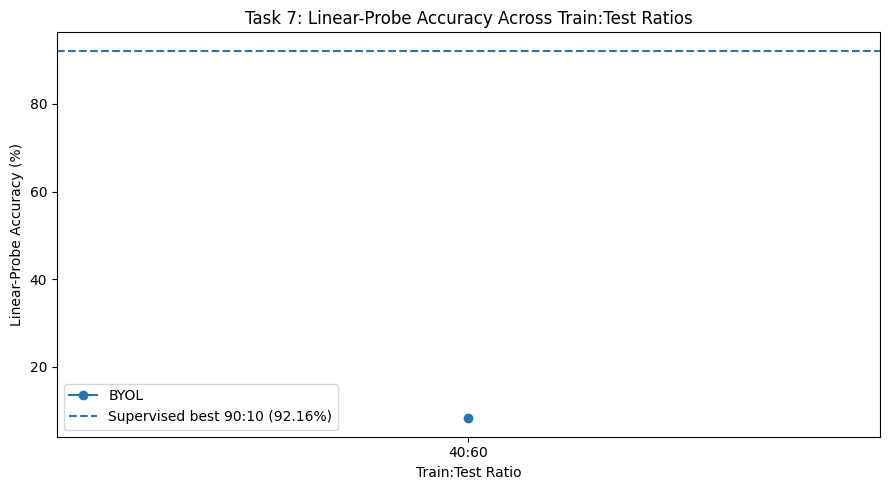

In [20]:

plt.figure(figsize=(9, 5))
for method in ratio_pivot.columns:
    plt.plot(ratio_pivot.index, ratio_pivot[method].values, marker='o', label=method)

# Optional supervised reference line from Task 2 best baseline @ 90:10
plt.axhline(CFG.SUPERVISED_BASELINE_90_10_ACC, linestyle='--', linewidth=1.5, label=f'Supervised best 90:10 ({CFG.SUPERVISED_BASELINE_90_10_ACC:.2f}%)')
plt.title('Task 7: Linear-Probe Accuracy Across Train:Test Ratios')
plt.xlabel('Train:Test Ratio')
plt.ylabel('Linear-Probe Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'task7_ratio_vs_lp_accuracy.png', dpi=200)
plt.show()


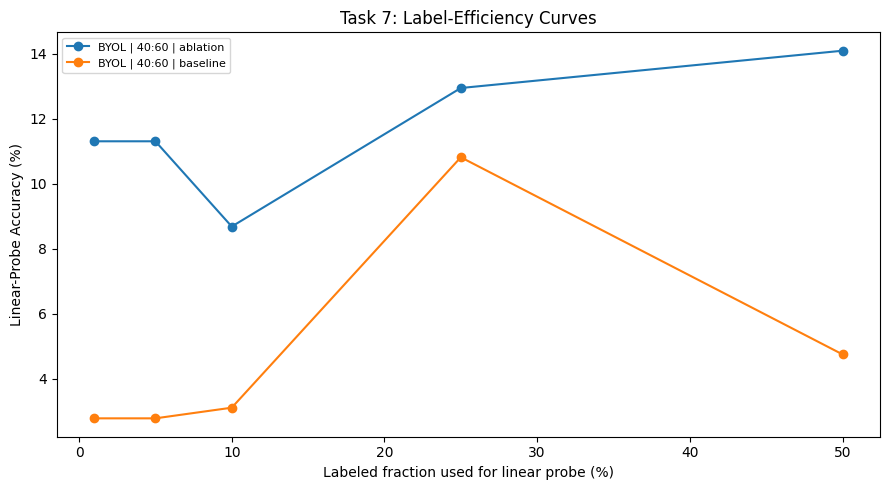

In [21]:

# Label-efficiency plot for the available results in this notebook
le_plot = label_eff_df.copy()
if len(le_plot) > 0:
    plt.figure(figsize=(9, 5))
    for (method, ratio, tag), sub in le_plot.groupby(['method', 'ratio', 'tag']):
        sub = sub.sort_values('label_frac')
        plt.plot(sub['label_frac'] * 100, sub['lp_accuracy'] * 100, marker='o', label=f'{method} | {ratio} | {tag}')
    plt.title('Task 7: Label-Efficiency Curves')
    plt.xlabel('Labeled fraction used for linear probe (%)')
    plt.ylabel('Linear-Probe Accuracy (%)')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'task7_label_efficiency_curves.png', dpi=200)
    plt.show()
else:
    print('No label-efficiency data available for plotting.')


In [22]:

if ablation_summary is not None and len(ablation_summary) > 0:
    plt.figure(figsize=(8, 4.5))
    plt.bar(ablation_summary['method'], ablation_summary['delta_lp_accuracy_pp'])
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.title('Task 7: Ablation Effect on Linear-Probe Accuracy (90:10)')
    plt.xlabel('SSL Method')
    plt.ylabel('Ablation - Baseline LP Accuracy (pp)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'task7_ablation_lp_delta.png', dpi=200)
    plt.show()


In [23]:
best_overall = baseline_df.sort_values('lp_accuracy', ascending=False).iloc[0]
print('Best baseline SSL result in Task 7 grid:')
print(best_overall[['method', 'backbone', 'ratio', 'lp_accuracy', 'lp_macro_f1', 'knn1_acc', 'knn5_acc']])

print('Pairwise significance quick view:')
required_cols = ['model_a', 'model_b', 'mean_diff_pp', 'paired_t_p', 'wilcoxon_p', 'paired_cohens_d']
if 'pairwise_stats' in globals() and isinstance(pairwise_stats, pd.DataFrame) and not pairwise_stats.empty:
    available_cols = [c for c in required_cols if c in pairwise_stats.columns]
    if available_cols:
        display(pairwise_stats[available_cols])
    else:
        print('Expected pairwise_stats columns not found.')
        print('Available columns:', pairwise_stats.columns.tolist())
        display(pairwise_stats)
else:
    print('pairwise_stats is empty or not created for this notebook.')

if 'friedman_p' in globals() and pd.notna(friedman_p):
    if friedman_p < 0.05:
        print(f'Friedman test is significant (p={friedman_p:.4g}), suggesting at least one SSL method differs across the matched ratios.')
    else:
        print(f'Friedman test is not significant (p={friedman_p:.4g}), so overall SSL differences may not be statistically reliable across ratios.')
else:
    print('Friedman result not available for this notebook.')


Best baseline SSL result in Task 7 grid:
method              BYOL
backbone        vit_b_16
ratio              40:60
lp_accuracy     8.196721
lp_macro_f1      8.31004
knn1_acc       19.180328
knn5_acc       15.901639
Name: 0, dtype: object
Pairwise significance quick view:
pairwise_stats is empty or not created for this notebook.
Friedman result not available for this notebook.


In [24]:

# Pack everything into a single zip for easy download from Kaggle output
artifacts_zip = OUT_DIR / 'task7_outputs.zip'
with zipfile.ZipFile(artifacts_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in [CKPT_DIR, TAB_DIR, FIG_DIR, LOG_DIR]:
        for fp in folder.rglob('*'):
            if fp.is_file():
                zf.write(fp, arcname=str(fp.relative_to(OUT_DIR)))
print('Created:', artifacts_zip)


Created: /kaggle/working/task7_byol_40_60/task7_outputs.zip


Visualizing method=BYOL, ratio=40:60, tag=baseline


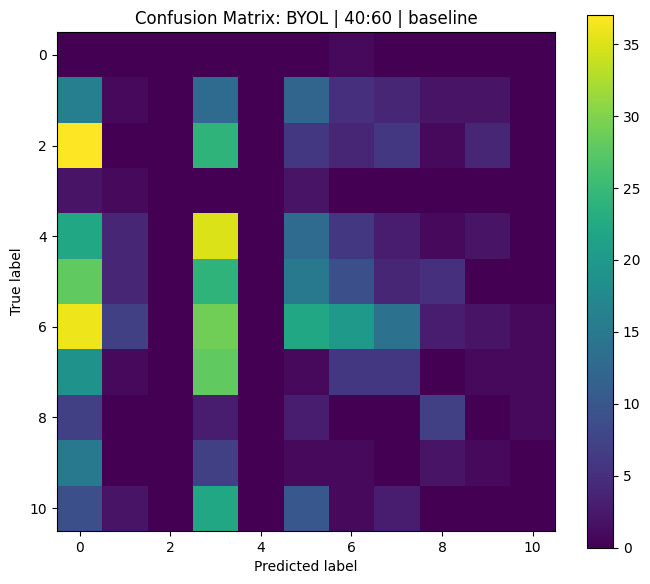

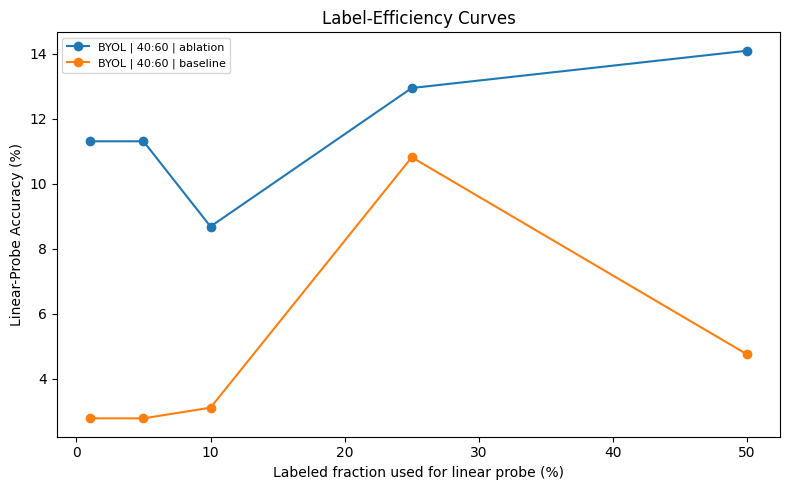

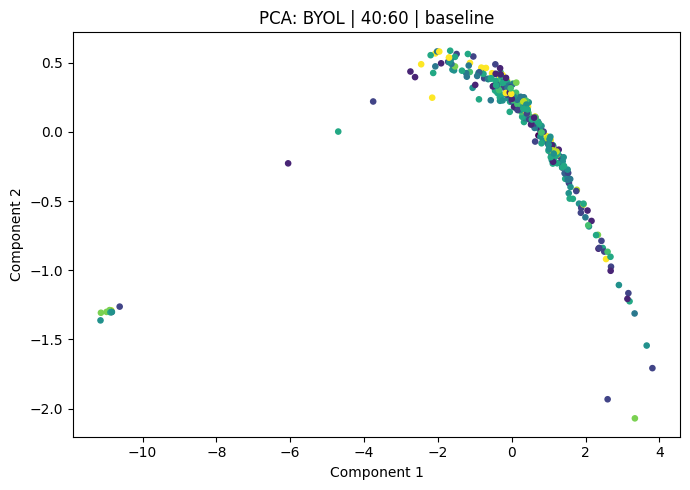

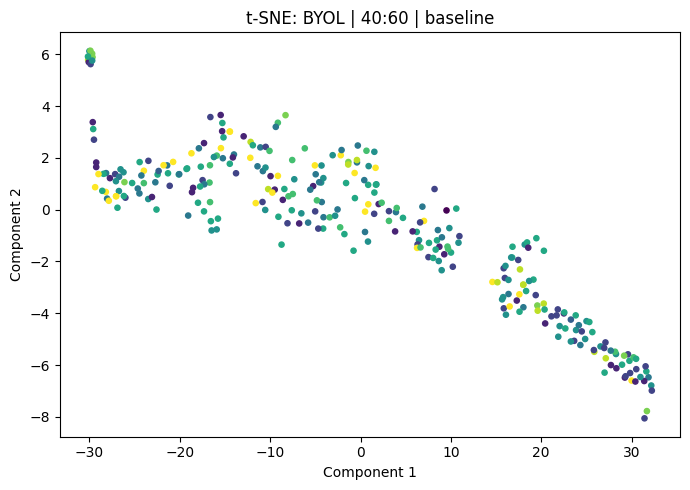

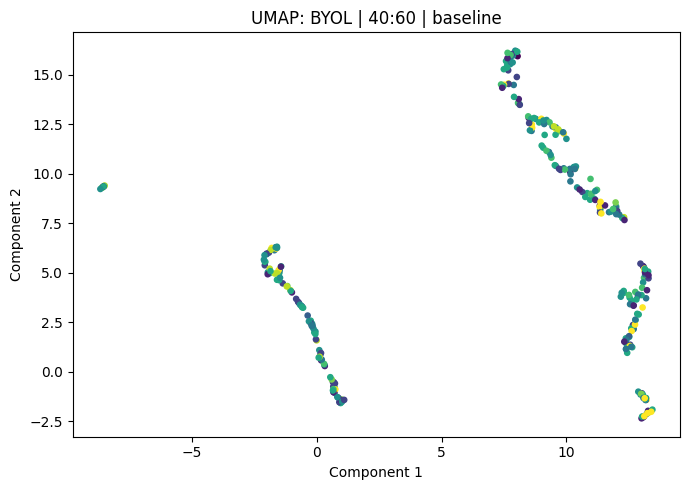

In [25]:
# Visual outputs: Confusion Matrix, Label-Efficiency Curve, PCA, t-SNE, UMAP
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_OK = True
except Exception:
    UMAP_OK = False

def _safe_scatter_2d(Z, y, title, save_path):
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(Z[:, 0], Z[:, 1], c=y, s=14)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

if 'results_df' in globals() and len(results_df) > 0:
    base_rows = results_df[results_df['tag'] == 'baseline'].copy()
    if len(base_rows) == 0:
        base_rows = results_df.copy()
    first_row = base_rows.iloc[0]
    method_name = str(first_row['method'])
    ratio_name = str(first_row['ratio'])
    tag = str(first_row['tag'])
    print(f'Visualizing method={method_name}, ratio={ratio_name}, tag={tag}')

    # 1) Confusion matrix
    cm_path = TAB_DIR / f'{method_name}_{ratio_name}_{tag}_confusion_matrix.npy'
    if cm_path.exists():
        cm = np.load(cm_path)
        plt.figure(figsize=(7, 6))
        plt.imshow(cm)
        plt.title(f'Confusion Matrix: {method_name} | {ratio_name} | {tag}')
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.colorbar()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f'{method_name}_{ratio_name}_{tag}_confusion_matrix.png', dpi=200)
        plt.show()
    else:
        print('Confusion matrix file not found:', cm_path)

    # 2) Label-efficiency curve for all available methods/rows in this notebook
    if 'label_eff_df' in globals() and len(label_eff_df) > 0:
        plt.figure(figsize=(8, 5))
        tmp = label_eff_df.copy()
        for (m, r, t), sub in tmp.groupby(['method', 'ratio', 'tag']):
            sub = sub.sort_values('label_frac')
            plt.plot(sub['label_frac'] * 100, sub['lp_accuracy'] * 100, marker='o', label=f'{m} | {r} | {t}')
        plt.title('Label-Efficiency Curves')
        plt.xlabel('Labeled fraction used for linear probe (%)')
        plt.ylabel('Linear-Probe Accuracy (%)')
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'task7_label_efficiency_curves.png', dpi=200)
        plt.show()
    else:
        print('label_eff_df is empty; skipping label-efficiency curve.')

    # 3) PCA / t-SNE / UMAP from saved feature file
    feat_path = TAB_DIR / f'{method_name}_{ratio_name}_{tag}_features_test.npz'
    if feat_path.exists():
        arr = np.load(feat_path)
        X = arr['X_te']
        y = arr['y_te']
        if len(X) > 300:
            rng = np.random.RandomState(42)
            idx = rng.choice(len(X), size=300, replace=False)
            X = X[idx]
            y = y[idx]
        # PCA
        try:
            Z_pca = PCA(n_components=2, random_state=42).fit_transform(X)
            _safe_scatter_2d(Z_pca, y, f'PCA: {method_name} | {ratio_name} | {tag}', FIG_DIR / f'{method_name}_{ratio_name}_{tag}_pca.png')
        except Exception as e:
            print('Skipping PCA due to:', e)
        # t-SNE
        try:
            perplexity = max(5, min(30, len(X) - 1))
            Z_tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=perplexity).fit_transform(X)
            _safe_scatter_2d(Z_tsne, y, f't-SNE: {method_name} | {ratio_name} | {tag}', FIG_DIR / f'{method_name}_{ratio_name}_{tag}_tsne.png')
        except Exception as e:
            print('Skipping t-SNE due to:', e)
        # UMAP
        if UMAP_OK:
            try:
                reducer = umap.UMAP(n_components=2, random_state=42)
                Z_umap = reducer.fit_transform(X)
                _safe_scatter_2d(Z_umap, y, f'UMAP: {method_name} | {ratio_name} | {tag}', FIG_DIR / f'{method_name}_{ratio_name}_{tag}_umap.png')
            except Exception as e:
                print('Skipping UMAP due to:', e)
        else:
            print('UMAP package unavailable; skipping UMAP plot.')
    else:
        print('Feature file not found; skipping PCA/t-SNE/UMAP:', feat_path)
else:
    print('results_df not available or empty; skipping visualization cell.')
